# Diagnostic Gap Decomposition of Codebook-FIGS Accuracy

This notebook demonstrates the **three-component gap decomposition** of Codebook-FIGS accuracy across 10 datasets and 3 source experiments.

**Gap definitions:**
- **Gap A** (oblique-vs-axis): measures FIGS oblique implementation quality
- **Gap B** (codebook constraint): isolates the pure cost of constraining splits to a learned codebook
- **Gap C** (optimizer range): shows sensitivity to optimization choices

The analysis includes Wilcoxon signed-rank tests, bootstrap confidence intervals, Cohen's d effect sizes, Spearman correlations with dataset properties, classification vs regression breakdown, and per-dataset attribution.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy, scipy — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import os

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-5c5e58-codebook-oblique-splits-learning-a-share/main/evaluation_iter4_diagnostic_gap/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'])} datasets")
print(f"Total examples: {sum(len(d['examples']) for d in data['datasets'])}")
print(f"Metadata keys: {sorted(data['metadata'].keys())}")

Loaded 10 datasets
Total examples: 30
Metadata keys: ['bottleneck_conclusion', 'bottleneck_reasoning', 'classification_vs_regression', 'correlation_summary', 'description', 'evaluation_name', 'fold_alignment', 'gap_definitions', 'n_datasets', 'n_folds', 'source_experiments', 'statistical_tests']


## Configuration

Tunable parameters for the statistical analysis. `N_BOOT` controls bootstrap CI precision, `N_PERM` controls permutation test precision.

In [5]:
# --- Config ---
N_BOOT = 10_000  # bootstrap iterations for CIs
N_PERM = 10_000  # permutation iterations for Spearman p-values
CI_LEVEL = 0.95  # confidence interval level
SEED = 42        # random seed for reproducibility

## Helper Functions

Statistical utility functions from the original evaluation script: bootstrap CI, Cohen's d effect size, and Spearman correlation with permutation-based p-value.

In [6]:
def bootstrap_ci(values: np.ndarray, n_boot: int = N_BOOT,
                 ci: float = CI_LEVEL, seed: int = SEED) -> tuple:
    """Bootstrap 95 % CI for the mean of *values*."""
    rng = np.random.RandomState(seed)
    boot_means = np.array([
        np.mean(rng.choice(values, size=len(values), replace=True))
        for _ in range(n_boot)
    ])
    alpha = (1 - ci) / 2
    lo = float(np.percentile(boot_means, 100 * alpha))
    hi = float(np.percentile(boot_means, 100 * (1 - alpha)))
    return lo, hi


def cohens_d(values: np.ndarray) -> float:
    """Cohen's d for a one-sample test (mean / std)."""
    if len(values) < 2 or np.std(values, ddof=1) == 0:
        return float("nan")
    return float(np.mean(values) / np.std(values, ddof=1))


def permutation_spearman_pvalue(x: np.ndarray, y: np.ndarray,
                                 n_perm: int = N_PERM,
                                 seed: int = SEED) -> tuple:
    """Spearman correlation with permutation-based p-value."""
    rng = np.random.RandomState(seed)
    rho_obs, _ = stats.spearmanr(x, y)
    count = 0
    for _ in range(n_perm):
        perm_y = rng.permutation(y)
        rho_perm, _ = stats.spearmanr(x, perm_y)
        if abs(rho_perm) >= abs(rho_obs):
            count += 1
    p_val = (count + 1) / (n_perm + 1)
    return float(rho_obs), float(p_val)


print("Helper functions defined.")

Helper functions defined.


## Extract Per-Dataset Gap Data

Parse the loaded evaluation output to extract per-dataset, per-fold gap values (A, B, B', C) along with dataset properties (task type, number of features/samples, effective rank).

In [7]:
# Extract per-dataset gap arrays from the evaluation output
gaps = {}
for ds_data in data["datasets"]:
    ds_name = ds_data["dataset"]
    examples = ds_data["examples"]

    gap_a_vals = [ex["eval_gap_a"] for ex in examples]
    gap_b_vals = [ex["eval_gap_b"] for ex in examples]
    gap_b_prime_vals = [ex["eval_gap_b_prime"] for ex in examples]
    gap_c_vals = [ex["eval_gap_c_range"] for ex in examples]
    total_gap_vals = [ex["eval_total_gap"] for ex in examples]
    erank_vals = [ex["eval_erank_figs_axis"] for ex in examples]
    figs_axis_vals = [float(ex["predict_figs_axis_aligned"]) for ex in examples]

    gaps[ds_name] = {
        "task_type": examples[0]["metadata_task_type"],
        "n_features": examples[0]["metadata_n_features"],
        "n_samples": examples[0]["metadata_n_samples"],
        "gap_a": np.array(gap_a_vals),
        "gap_b": np.array(gap_b_vals),
        "gap_b_prime": np.array(gap_b_prime_vals),
        "gap_c": np.array(gap_c_vals),
        "total_gap": np.array(total_gap_vals),
        "erank_figs_axis": np.array(erank_vals),
        "figs_axis_scores": np.array(figs_axis_vals),
    }

datasets = sorted(gaps.keys())
n_ds = len(datasets)
print(f"Extracted gap data for {n_ds} datasets: {datasets}")

Extracted gap data for 10 datasets: ['auto_mpg', 'breast_cancer_wdbc', 'california_housing', 'credit_german', 'diabetes_pima', 'diabetes_regression', 'heart_disease', 'ionosphere', 'spambase', 'wine_quality_red']


## Statistical Analysis

Run the full suite of statistical tests from the original evaluation:
1. **Wilcoxon signed-rank tests** — test whether each gap differs from zero
2. **Bootstrap confidence intervals** — non-parametric CIs for mean gaps
3. **Cohen's d effect sizes** — standardized magnitude of each gap
4. **Spearman correlations** — relationship between Gap B and dataset properties

In [8]:
# ---- Per-dataset means ----
ds_mean_gap_a = np.array([float(np.mean(gaps[d]["gap_a"])) for d in datasets])
ds_mean_gap_b = np.array([float(np.mean(gaps[d]["gap_b"])) for d in datasets])
ds_mean_gap_b_prime = np.array([float(np.mean(gaps[d]["gap_b_prime"])) for d in datasets])
ds_mean_gap_c = np.array([float(np.mean(gaps[d]["gap_c"])) for d in datasets])
ds_mean_total = np.array([float(np.mean(gaps[d]["total_gap"])) for d in datasets])

print("Per-dataset mean Gap A:", np.round(ds_mean_gap_a, 4))
print("Per-dataset mean Gap B:", np.round(ds_mean_gap_b, 4))
print("Per-dataset mean Gap C:", np.round(ds_mean_gap_c, 4))

# ---- Wilcoxon signed-rank tests ----
if n_ds >= 6:
    try:
        stat_a, p_a = stats.wilcoxon(ds_mean_gap_a, alternative="two-sided")
    except ValueError:
        stat_a, p_a = float("nan"), float("nan")
    try:
        stat_b, p_b = stats.wilcoxon(ds_mean_gap_b, alternative="two-sided")
    except ValueError:
        stat_b, p_b = float("nan"), float("nan")
    try:
        stat_bp, p_bp = stats.wilcoxon(ds_mean_gap_b_prime, alternative="two-sided")
    except ValueError:
        stat_bp, p_bp = float("nan"), float("nan")
    # Paired |Gap A| vs |Gap B| magnitude
    try:
        stat_ab, p_ab = stats.wilcoxon(
            np.abs(ds_mean_gap_a), np.abs(ds_mean_gap_b),
            alternative="two-sided"
        )
    except ValueError:
        stat_ab, p_ab = float("nan"), float("nan")
else:
    stat_a = p_a = stat_b = p_b = stat_bp = p_bp = stat_ab = p_ab = float("nan")

print(f"\nWilcoxon Gap A: stat={stat_a:.4f}, p={p_a:.4f}")
print(f"Wilcoxon Gap B: stat={stat_b:.4f}, p={p_b:.4f}")
print(f"Wilcoxon Gap B' (within-exp): stat={stat_bp:.4f}, p={p_bp:.4f}")
print(f"Wilcoxon |A| vs |B|: stat={stat_ab:.4f}, p={p_ab:.4f}")

# ---- Bootstrap CIs ----
ci_gap_a = bootstrap_ci(ds_mean_gap_a)
ci_gap_b = bootstrap_ci(ds_mean_gap_b)
ci_gap_b_prime = bootstrap_ci(ds_mean_gap_b_prime)
ci_gap_c = bootstrap_ci(ds_mean_gap_c)
print(f"\nBootstrap CI Gap A: [{ci_gap_a[0]:.4f}, {ci_gap_a[1]:.4f}]")
print(f"Bootstrap CI Gap B: [{ci_gap_b[0]:.4f}, {ci_gap_b[1]:.4f}]")
print(f"Bootstrap CI Gap B': [{ci_gap_b_prime[0]:.4f}, {ci_gap_b_prime[1]:.4f}]")
print(f"Bootstrap CI Gap C: [{ci_gap_c[0]:.4f}, {ci_gap_c[1]:.4f}]")

# ---- Cohen's d ----
d_gap_a = cohens_d(ds_mean_gap_a)
d_gap_b = cohens_d(ds_mean_gap_b)
d_gap_b_prime = cohens_d(ds_mean_gap_b_prime)
print(f"\nCohen's d Gap A: {d_gap_a:.4f}")
print(f"Cohen's d Gap B: {d_gap_b:.4f}")
print(f"Cohen's d Gap B': {d_gap_b_prime:.4f}")

Per-dataset mean Gap A: [ 0.0803 -0.0029  0.1821  0.015  -0.0303  0.1127  0.0108  0.0566  0.23
  0.0957]
Per-dataset mean Gap B: [-0.0259 -0.0088  0.065  -0.0467  0.0238 -0.226  -0.0221 -0.0141 -0.2227
 -0.0144]
Per-dataset mean Gap C: [0.2302 0.0848 0.1701 0.095  0.0693 0.3313 0.1124 0.0947 0.1648 0.1279]

Wilcoxon Gap A: stat=5.0000, p=0.0195
Wilcoxon Gap B: stat=13.0000, p=0.1602
Wilcoxon Gap B' (within-exp): stat=23.0000, p=0.6953
Wilcoxon |A| vs |B|: stat=19.0000, p=0.4316



Bootstrap CI Gap A: [0.0280, 0.1249]
Bootstrap CI Gap B: [-0.1127, 0.0015]
Bootstrap CI Gap B': [-0.0266, 0.0840]
Bootstrap CI Gap C: [0.1058, 0.2005]

Cohen's d Gap A: 0.8993
Cohen's d Gap B: -0.5059
Cohen's d Gap B': 0.2475


## Spearman Correlations and Classification vs Regression Breakdown

Test whether Gap B correlates with dataset properties (number of features, samples, effective rank, baseline performance) and whether it differs between classification and regression tasks.

In [9]:
# ---- Spearman correlations with permutation p-values ----
n_features = np.array([gaps[d]["n_features"] for d in datasets], dtype=float)
n_samples = np.array([gaps[d]["n_samples"] for d in datasets], dtype=float)
mean_erank = np.array(
    [float(np.mean(gaps[d]["erank_figs_axis"])) for d in datasets]
)
mean_baseline = np.array(
    [float(np.mean(gaps[d]["figs_axis_scores"])) for d in datasets]
)

corr_nfeat_rho, corr_nfeat_p = permutation_spearman_pvalue(ds_mean_gap_b, n_features)
corr_nsamp_rho, corr_nsamp_p = permutation_spearman_pvalue(ds_mean_gap_b, n_samples)
corr_erank_rho, corr_erank_p = permutation_spearman_pvalue(ds_mean_gap_b, mean_erank)
corr_baseline_rho, corr_baseline_p = permutation_spearman_pvalue(ds_mean_gap_b, mean_baseline)

print(f"Corr(Gap B, n_features): rho={corr_nfeat_rho:.3f}, p={corr_nfeat_p:.4f}")
print(f"Corr(Gap B, n_samples):  rho={corr_nsamp_rho:.3f}, p={corr_nsamp_p:.4f}")
print(f"Corr(Gap B, eRank):      rho={corr_erank_rho:.3f}, p={corr_erank_p:.4f}")
print(f"Corr(Gap B, baseline):   rho={corr_baseline_rho:.3f}, p={corr_baseline_p:.4f}")

# ---- Classification vs Regression breakdown ----
clf_ds = [d for d in datasets if gaps[d]["task_type"] == "classification"]
reg_ds = [d for d in datasets if gaps[d]["task_type"] == "regression"]

clf_gap_b = np.array([float(np.mean(gaps[d]["gap_b"])) for d in clf_ds])
reg_gap_b = np.array([float(np.mean(gaps[d]["gap_b"])) for d in reg_ds])

if len(clf_gap_b) >= 2 and len(reg_gap_b) >= 2:
    try:
        u_stat, u_p = stats.mannwhitneyu(clf_gap_b, reg_gap_b, alternative="two-sided")
    except ValueError:
        u_stat, u_p = float("nan"), float("nan")
else:
    u_stat, u_p = float("nan"), float("nan")

print(f"\nClassification Gap B (n={len(clf_ds)}): mean={np.mean(clf_gap_b):.4f}, std={np.std(clf_gap_b):.4f}")
print(f"Regression Gap B (n={len(reg_ds)}):     mean={np.mean(reg_gap_b):.4f}, std={np.std(reg_gap_b):.4f}")
print(f"Mann-Whitney U: stat={u_stat:.2f}, p={u_p:.4f}")

Corr(Gap B, n_features): rho=-0.457, p=0.1890
Corr(Gap B, n_samples):  rho=0.164, p=0.6550
Corr(Gap B, eRank):      rho=-0.491, p=0.1555
Corr(Gap B, baseline):   rho=0.188, p=0.6139

Classification Gap B (n=6): mean=-0.0484, std=0.0807
Regression Gap B (n=4):     mean=-0.0503, std=0.1073
Mann-Whitney U: stat=13.00, p=0.9143


## Decision Framework and Gap Identity Verification

Determine the primary bottleneck based on statistical evidence and verify the gap identity (Total Gap = Gap A + Gap B).

In [10]:
# ---- Per-dataset attribution ----
per_ds_attribution = {}
for d in datasets:
    mean_a = float(np.mean(gaps[d]["gap_a"]))
    mean_b = float(np.mean(gaps[d]["gap_b"]))
    total_abs = abs(mean_a) + abs(mean_b)
    if total_abs > 1e-12:
        pct_a = abs(mean_a) / total_abs * 100
        pct_b = abs(mean_b) / total_abs * 100
    else:
        pct_a = pct_b = 50.0
    opposite = (mean_a > 0 and mean_b < 0) or (mean_a < 0 and mean_b > 0)
    per_ds_attribution[d] = {
        "pct_gap_a": pct_a, "pct_gap_b": pct_b, "opposite_signs": opposite,
    }

# ---- Gap identity check ----
identity_residual = float(
    np.mean(np.abs(ds_mean_total - (ds_mean_gap_a + ds_mean_gap_b)))
)
print(f"Gap identity check: |Total - (A + B)| mean = {identity_residual:.8f}")

# ---- Recoverable gap ----
overall_mean_a = float(np.mean(ds_mean_gap_a))
overall_mean_c = float(np.mean(ds_mean_gap_c))
overall_mean_total = float(np.mean(ds_mean_total))
recoverable = overall_mean_a + overall_mean_c

# ---- Decision framework ----
gap_b_significant = p_b < 0.05 if not np.isnan(p_b) else False
gap_a_dominates = float(np.mean(np.abs(ds_mean_gap_a))) > float(
    np.mean(np.abs(ds_mean_gap_b))
)
gap_c_dominates = overall_mean_c > abs(float(np.mean(ds_mean_gap_b)))

if not gap_b_significant:
    bottleneck = "implementation"
    reasoning = (
        f"Gap B (codebook constraint) is NOT statistically significant "
        f"(p={p_b:.4f}), meaning the codebook constraint is essentially "
        "free. Performance loss comes from other sources."
    )
elif gap_a_dominates:
    bottleneck = "implementation"
    reasoning = (
        f"Gap A (oblique implementation) dominates Gap B "
        f"(|A|={float(np.mean(np.abs(ds_mean_gap_a))):.4f} > "
        f"|B|={float(np.mean(np.abs(ds_mean_gap_b))):.4f}), "
        "meaning the oblique FIGS implementation is the bottleneck."
    )
elif gap_c_dominates:
    bottleneck = "optimizer"
    reasoning = (
        f"Gap C (optimizer range) exceeds |Gap B| "
        f"(C={overall_mean_c:.4f} > |B|={abs(float(np.mean(ds_mean_gap_b))):.4f}), "
        "suggesting the codebook idea is sound but optimization is undertrained."
    )
else:
    bottleneck = "codebook_constraint"
    reasoning = (
        "Gap B is significant and dominates both Gap A and Gap C, "
        "suggesting the codebook constraint itself is the primary bottleneck."
    )

print(f"\nBOTTLENECK: {bottleneck}")
print(f"REASONING: {reasoning}")

Gap identity check: |Total - (A + B)| mean = 0.00000030

BOTTLENECK: implementation
REASONING: Gap B (codebook constraint) is NOT statistically significant (p=0.1602), meaning the codebook constraint is essentially free. Performance loss comes from other sources.


## Results Summary and Visualization

Display key results in a readable table and visualize the gap decomposition across datasets.

DIAGNOSTIC GAP DECOMPOSITION - SUMMARY
Metric                                Value              CI / p-value
----------------------------------------------------------------------
Mean Gap A (oblique-vs-axis)        +0.0750          [0.0280, 0.1249]
Mean Gap B (codebook)               -0.0492         [-0.1127, 0.0015]
Mean Gap B' (within-exp)            +0.0233         [-0.0266, 0.0840]
Mean Gap C (optimizer range)        +0.1480          [0.1058, 0.2005]
----------------------------------------------------------------------
Wilcoxon Gap A p-value               0.0195
Wilcoxon Gap B p-value               0.1602
Gap B significant (p<0.05)?              NO
Identity residual                  3.00e-07
Bottleneck                     implementation

Dataset                   Type      Gap A    Gap B    Gap C    Total
-----------------------------------------------------------------
auto_mpg                  reg     +0.0803  -0.0259  +0.2302  +0.0544
breast_cancer_wdbc        clf     -0.0029 

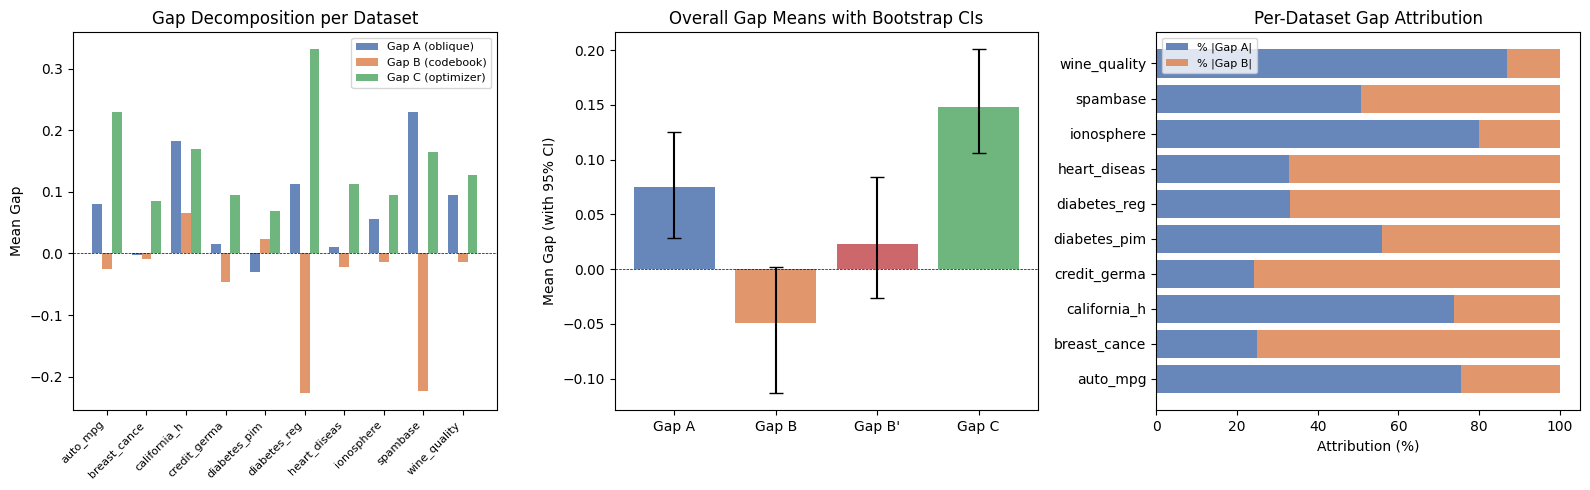


Figure saved to gap_decomposition.png


In [11]:
# ---- Results summary table ----
print("=" * 70)
print("DIAGNOSTIC GAP DECOMPOSITION - SUMMARY")
print("=" * 70)
gap_bp_label = "Mean Gap B' (within-exp)"
print(f"{'Metric':<30} {'Value':>12} {'CI / p-value':>25}")
print("-" * 70)
ci_a_str = f"[{ci_gap_a[0]:.4f}, {ci_gap_a[1]:.4f}]"
ci_b_str = f"[{ci_gap_b[0]:.4f}, {ci_gap_b[1]:.4f}]"
ci_bp_str = f"[{ci_gap_b_prime[0]:.4f}, {ci_gap_b_prime[1]:.4f}]"
ci_c_str = f"[{ci_gap_c[0]:.4f}, {ci_gap_c[1]:.4f}]"
mean_b = float(np.mean(ds_mean_gap_b))
mean_bp = float(np.mean(ds_mean_gap_b_prime))
print(f"{'Mean Gap A (oblique-vs-axis)':<30} {overall_mean_a:>+12.4f} {ci_a_str:>25}")
print(f"{'Mean Gap B (codebook)':<30} {mean_b:>+12.4f} {ci_b_str:>25}")
print(f"{gap_bp_label:<30} {mean_bp:>+12.4f} {ci_bp_str:>25}")
print(f"{'Mean Gap C (optimizer range)':<30} {overall_mean_c:>+12.4f} {ci_c_str:>25}")
print("-" * 70)
print(f"{'Wilcoxon Gap A p-value':<30} {p_a:>12.4f}")
print(f"{'Wilcoxon Gap B p-value':<30} {p_b:>12.4f}")
sig_str = "YES" if gap_b_significant else "NO"
print(f"{'Gap B significant (p<0.05)?':<30} {sig_str:>12}")
print(f"{'Identity residual':<30} {identity_residual:>12.2e}")
print(f"{'Bottleneck':<30} {bottleneck:>12}")
print("=" * 70)

# ---- Per-dataset breakdown ----
header = f"{'Dataset':<25} {'Type':<6} {'Gap A':>8} {'Gap B':>8} {'Gap C':>8} {'Total':>8}"
print(f"\n{header}")
print("-" * 65)
for i, d in enumerate(datasets):
    tt = "clf" if gaps[d]["task_type"] == "classification" else "reg"
    print(f"{d:<25} {tt:<6} {ds_mean_gap_a[i]:>+8.4f} {ds_mean_gap_b[i]:>+8.4f} {ds_mean_gap_c[i]:>+8.4f} {ds_mean_total[i]:>+8.4f}")

# ---- Visualization ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Gap decomposition per dataset (grouped bar)
short_names = [d[:12] for d in datasets]
x = np.arange(n_ds)
w = 0.25
axes[0].bar(x - w, ds_mean_gap_a, w, label="Gap A (oblique)", color="#4C72B0", alpha=0.85)
axes[0].bar(x, ds_mean_gap_b, w, label="Gap B (codebook)", color="#DD8452", alpha=0.85)
axes[0].bar(x + w, ds_mean_gap_c, w, label="Gap C (optimizer)", color="#55A868", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(short_names, rotation=45, ha="right", fontsize=8)
axes[0].set_ylabel("Mean Gap")
axes[0].set_title("Gap Decomposition per Dataset")
axes[0].legend(fontsize=8)
axes[0].axhline(y=0, color="black", linewidth=0.5, linestyle="--")

# Plot 2: Overall gap means with bootstrap CIs
gap_names = ["Gap A", "Gap B", "Gap B'", "Gap C"]
gap_means = [overall_mean_a, mean_b, mean_bp, overall_mean_c]
ci_los = [ci_gap_a[0], ci_gap_b[0], ci_gap_b_prime[0], ci_gap_c[0]]
ci_his = [ci_gap_a[1], ci_gap_b[1], ci_gap_b_prime[1], ci_gap_c[1]]
colors = ["#4C72B0", "#DD8452", "#C44E52", "#55A868"]
yerr_lo = [m - lo for m, lo in zip(gap_means, ci_los)]
yerr_hi = [hi - m for m, hi in zip(gap_means, ci_his)]
axes[1].bar(gap_names, gap_means, color=colors, alpha=0.85,
            yerr=[yerr_lo, yerr_hi], capsize=5, ecolor="black")
axes[1].axhline(y=0, color="black", linewidth=0.5, linestyle="--")
axes[1].set_ylabel("Mean Gap (with 95% CI)")
axes[1].set_title("Overall Gap Means with Bootstrap CIs")

# Plot 3: Per-dataset attribution (% Gap A vs % Gap B)
pct_a_vals = [per_ds_attribution[d]["pct_gap_a"] for d in datasets]
pct_b_vals = [per_ds_attribution[d]["pct_gap_b"] for d in datasets]
axes[2].barh(short_names, pct_a_vals, label="% |Gap A|", color="#4C72B0", alpha=0.85)
axes[2].barh(short_names, pct_b_vals, left=pct_a_vals, label="% |Gap B|", color="#DD8452", alpha=0.85)
axes[2].set_xlabel("Attribution (%)")
axes[2].set_title("Per-Dataset Gap Attribution")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("gap_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nFigure saved to gap_decomposition.png")